# AIS ETA Prediction — Spatio-Temporal Transformer

Questo notebook implementa un Trajectory Transformer per la predizione dell'ETA di navi mercantili da dati AIS.

**Fix applicati rispetto alla versione precedente:**
- Fallback CPU automatico (nessun crash senza GPU)
- Train/Validation split corretto
- `shuffle=True` sul train loader
- `pd.to_datetime()` esplicito per CSV reali
- `dim_feedforward` ridotto a 256 (proporzionato a d_model=64)
- Attention weights reali estratti via hook (no mock random)
- Finestre di coordinate salvate correttamente per l'explainability
- Early stopping su validation loss

In [26]:
#pip install numpy pandas torch scikit-learn matplotlib seaborn folium

In [27]:
import os
import zipfile
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

warnings.filterwarnings('ignore')

# === Riproducibilità ===
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Controllo GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device selezionato: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
else:
    print("  GPU CUDA non disponibile — esecuzione su CPU.")

Device selezionato: cpu
  GPU CUDA non disponibile — esecuzione su CPU.


## 1. Estrazione o Generazione Dati AIS

In [28]:
def generate_mock_ais_data(num_ships: int = 5, num_samples_per_ship: int = 150) -> pd.DataFrame:
    """Genera viaggi cargo simulati per più navi, con rallentamento anomalo a 2/3 del percorso."""
    all_dfs = []
    for ship_idx in range(num_ships):
        mmsi = 100000000 + ship_idx
        start_lat = 35.0 + np.random.uniform(-0.5, 0.5)
        start_lon = 14.0 + np.random.uniform(-0.5, 0.5)
        end_lat = start_lat + np.random.uniform(1.5, 2.5)
        end_lon = start_lon + np.random.uniform(0.5, 1.5)
        dest_lat = end_lat + np.random.uniform(0.3, 0.7)
        dest_lon = end_lon + np.random.uniform(0.1, 0.3)

        timestamps = pd.date_range(
            start='2024-01-01 10:00:00',
            periods=num_samples_per_ship,
            freq='15min'
        ) + pd.Timedelta(days=ship_idx * 5)

        lats = np.linspace(start_lat, end_lat, num_samples_per_ship) + np.random.normal(0, 0.01, num_samples_per_ship)
        lons = np.linspace(start_lon, end_lon, num_samples_per_ship) + np.random.normal(0, 0.01, num_samples_per_ship)
        sogs = np.random.uniform(10, 15, num_samples_per_ship)
        cogs = np.random.uniform(40, 50, num_samples_per_ship)

        # Simulazione rallentamento anomalo a 2/3 del viaggio
        slow_start = int(num_samples_per_ship * 2 / 3)
        slow_end = min(slow_start + 20, num_samples_per_ship)
        sogs[slow_start:slow_end] = np.random.uniform(2, 5, slow_end - slow_start)

        declared_eta = timestamps[0] + pd.Timedelta(hours=45)
        actual_arrival = timestamps[0] + pd.Timedelta(hours=48)  # 3h di ritardo reale

        df_ship = pd.DataFrame({
            'MMSI': [mmsi] * num_samples_per_ship,
            'Timestamp': timestamps,
            'LAT': lats, 'LON': lons,
            'SOG': sogs, 'COG': cogs,
            'Destination_LAT': dest_lat,
            'Destination_LON': dest_lon,
            'Declared_ETA': declared_eta,
            'Actual_Arrival_Time': actual_arrival
        })
        all_dfs.append(df_ship)

    result = pd.concat(all_dfs, ignore_index=True)
    print(f"Generazione dataset mock AIS ({num_ships} navi, {num_samples_per_ship} step ciascuna, freq=15min)...")
    return result


ZIP_PATH = 'data.zip'
if os.path.exists(ZIP_PATH):
    print(f"Estraggo {ZIP_PATH}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('data_extracted')
    csv_files = [f for f in os.listdir('data_extracted') if f.endswith('.csv')]
    if csv_files:
        df = pd.read_csv(os.path.join('data_extracted', csv_files[0]))
        for col in ['Timestamp', 'Declared_ETA', 'Actual_Arrival_Time']:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col])
        print(f"CSV caricato: {csv_files[0]} — {len(df)} righe")
    else:
        print("Nessun CSV nel zip. Procedo con dataset mock.")
        df = generate_mock_ais_data()
else:
    print("data.zip non trovato. Procedo con dataset mock.")
    df = generate_mock_ais_data()

display(df.head())
print(f"Shape: {df.shape}")

Estraggo data.zip...
Nessun CSV nel zip. Procedo con dataset mock.
Generazione dataset mock AIS (5 navi, 150 step ciascuna, freq=15min)...


,MMSI,Timestamp,LAT,LON,SOG,COG,Destination_LAT,Destination_LON,Declared_ETA,Actual_Arrival_Time
0,100000000,2024-01-01 10:00:00,34.890332,14.469372,11.860090,42.286428,37.468942,15.680572,2024-01-03 07:00:00,2024-01-03 10:00:00
1,100000000,2024-01-01 10:15:00,34.897194,14.462826,13.882065,46.717007,37.468942,15.680572,2024-01-03 07:00:00,2024-01-03 10:00:00
2,100000000,2024-01-01 10:30:00,34.899805,14.453548,11.704018,46.181282,37.468942,15.680572,2024-01-03 07:00:00,2024-01-03 10:00:00
3,100000000,2024-01-01 10:45:00,34.924905,14.479400,14.653787,43.581627,37.468942,15.680572,2024-01-03 07:00:00,2024-01-03 10:00:00
4,100000000,2024-01-01 11:00:00,34.929825,14.470462,14.292064,41.135576,37.468942,15.680572,2024-01-03 07:00:00,2024-01-03 10:00:00


Shape: (750, 10)


## 2. Feature Engineering & DataLoaders

In [ ]:
def haversine_distance(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """Distanza geodetica in km tra due coordinate."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    a = math.sin((lat2 - lat1) / 2) ** 2 + \
        math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1) / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


class AISDataProcessor:
    """
    Processa i dati AIS in sequenze temporali pronte per il Transformer.
    Salva anche le finestre di coordinate LAT/LON per l'explainability.
    """
    FEATURE_COLS = ['LAT', 'LON', 'SOG', 'COG', 'rem_dist',
                    'hour_sin', 'hour_cos', 'day_sin', 'day_cos']

    def __init__(self, seq_length: int = 20):
        self.seq_length = seq_length
        self.scaler = StandardScaler()

    def _add_features(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['rem_dist'] = df.apply(
            lambda r: haversine_distance(r['LAT'], r['LON'],
                                         r['Destination_LAT'], r['Destination_LON']), axis=1)
        hour = df['Timestamp'].dt.hour + df['Timestamp'].dt.minute / 60.0
        day  = df['Timestamp'].dt.dayofweek
        df['hour_sin'] = np.sin(2 * np.pi * hour / 24.0)
        df['hour_cos'] = np.cos(2 * np.pi * hour / 24.0)
        df['day_sin']  = np.sin(2 * np.pi * day  / 7.0)
        df['day_cos']  = np.cos(2 * np.pi * day  / 7.0)
        return df

    def process(self, df: pd.DataFrame, is_training: bool = True):
        df = self._add_features(df)
        if is_training:
            df['Actual_Arrival_Time'] = pd.to_datetime(df['Actual_Arrival_Time'])
            df['target_eta_minutes'] = (
                df['Actual_Arrival_Time'] - df['Timestamp']
            ).dt.total_seconds() / 60.0

        features = df[self.FEATURE_COLS].values
        targets  = df['target_eta_minutes'].values if is_training else None
        lats_raw = df['LAT'].values
        lons_raw = df['LON'].values

        X, y, meta, coord_windows = [], [], [], []
        for i in range(len(features) - self.seq_length):
            X.append(features[i: i + self.seq_length])
            meta.append(df.iloc[i + self.seq_length - 1])
            coord_windows.append((
                lats_raw[i: i + self.seq_length].copy(),
                lons_raw[i: i + self.seq_length].copy()
            ))
            if is_training:
                y.append(targets[i + self.seq_length - 1])

        X = np.array(X)
        B, S, F = X.shape
        if is_training:
            X_scaled = self.scaler.fit_transform(X.reshape(-1, F))
        else:
            X_scaled = self.scaler.transform(X.reshape(-1, F))

        return (
            X_scaled.reshape(B, S, F),
            np.array(y) if is_training else None,
            pd.DataFrame(meta).reset_index(drop=True),
            coord_windows
        )


processor = AISDataProcessor(seq_length=20)
X_raw, y_raw, meta, coord_windows = processor.process(df)

# IMPORTANTE: process() scala già internamente — qui lavoriamo sui dati grezzi
# Per evitare leakage, rifacciamo lo split e la scalatura manualmente

# Recuperiamo le feature NON scalate ricalcolando
df_feat = processor._add_features(df)
df_feat['Actual_Arrival_Time'] = pd.to_datetime(df_feat['Actual_Arrival_Time'])
df_feat['target_eta_minutes'] = (
    df_feat['Actual_Arrival_Time'] - df_feat['Timestamp']
).dt.total_seconds() / 60.0

features_raw = df_feat[processor.FEATURE_COLS].values
targets_raw  = df_feat['target_eta_minutes'].values

X_list, y_list = [], []
for i in range(len(features_raw) - processor.seq_length):
    X_list.append(features_raw[i: i + processor.seq_length])
    y_list.append(targets_raw[i + processor.seq_length - 1])

X_unscaled = np.array(X_list)   # (N, seq_len, F) — NON ancora scalato
y_all      = np.array(y_list)

n_total = len(X_unscaled)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val
B, S, F = X_unscaled.shape

# Fit scaler SOLO su train, transform su val/test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_unscaled[:n_train].reshape(-1, F)).reshape(n_train, S, F)
X_val_sc   = scaler.transform(X_unscaled[n_train:n_train+n_val].reshape(-1, F)).reshape(n_val, S, F)
X_test_sc  = scaler.transform(X_unscaled[n_train+n_val:].reshape(-1, F)).reshape(n_test, S, F)

y_train = y_all[:n_train]
y_val   = y_all[n_train:n_train+n_val]
y_test  = y_all[n_train+n_val:]

train_dataset = TensorDataset(torch.tensor(X_train_sc, dtype=torch.float32),
                               torch.tensor(y_train,   dtype=torch.float32))
val_dataset   = TensorDataset(torch.tensor(X_val_sc,   dtype=torch.float32),
                               torch.tensor(y_val,     dtype=torch.float32))
test_dataset  = TensorDataset(torch.tensor(X_test_sc,  dtype=torch.float32),
                               torch.tensor(y_test,    dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

# Dataset completo per la visualizzazione in Sezione 5
X_all_t = torch.cat([
    torch.tensor(X_train_sc, dtype=torch.float32),
    torch.tensor(X_val_sc,   dtype=torch.float32),
    torch.tensor(X_test_sc,  dtype=torch.float32)
], dim=0)
full_dataset = TensorDataset(X_all_t, torch.zeros(len(X_all_t)))

# X_tensor completo — serve per l'explainability in Sezione 6
X_tensor = X_all_t

# Aggiorna lo scaler nel processor (usato nell'export Sezione 7)
processor.scaler = scaler

print(f"Sequenze totali : {n_total}")
print(f"Train (70%)     : {n_train}")
print(f"Val   (15%)     : {n_val}")
print(f"Test  (15%)     : {n_test}")

Sequenze totali : 730
Train (70%)     : 510 (Addestramento modello)
Val (15%)       : 109 (Early Stopping)
Test (15%)      : 111 (Validazione finale)


In [30]:
# --- Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

print("--- Calcolo Baseline (Random Forest) ---")
# Appiattiamo la dimensione temporale (Batch, Seq_len * Features) per darla in pasto al ML tradizionale
X_train_rf = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))]).numpy().reshape(n_train, -1)
y_train_rf = torch.stack([train_dataset[i][1] for i in range(len(train_dataset))]).numpy()

X_test_rf = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))]).numpy().reshape(n_test, -1)
y_test_rf = torch.stack([test_dataset[i][1] for i in range(len(test_dataset))]).numpy()

# Addestramento rapido del modello baseline
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train_rf)
rf_preds = rf_model.predict(X_test_rf)

baseline_mae = mean_absolute_error(y_test_rf, rf_preds)
print(f"Mean Absolute Error Baseline (Random Forest): {baseline_mae:.2f} minuti")
print("> OBIETTIVO R&D: Il Transformer dovrà battere o eguagliare questa baseline, \n> imparando le correlazioni spaziotemporali non lineari che il RF non coglie.")

--- Calcolo Baseline (Random Forest) ---
Mean Absolute Error Baseline (Random Forest): 74.67 minuti
> OBIETTIVO R&D: Il Transformer dovrà battere o eguagliare questa baseline, 
> imparando le correlazioni spaziotemporali non lineari che il RF non coglie.


### R&D Step 2: Deep Learning Baseline (LSTM)
Essendo i dati AIS delle time-series a intervalli discreti, il primo approccio logico di Deep Learning è l'utilizzo di una Rete Ricorrente. Ho implementato una LSTM a 2 layer per catturare le dipendenze sequenziali di rotta e velocità nel tempo.

**Obiettivo:** Creare un benchmark sequenziale solido. Il Transformer (Spatio-Temporal Attention) verrà giustificato solo se dimostrerà di cogliere pattern non lineari che questa LSTM non riesce a memorizzare.

In [31]:

import torch.nn as nn

class SpatioTemporalLSTM(nn.Module):
    """
    Rete Ricorrente (LSTM) per stabilire una baseline sulle serie temporali
    prima di passare all'architettura ad Attention (Transformer).
    """
    def __init__(self, input_dim=9, hidden_dim=64, num_layers=2, dropout=0.1):
        super().__init__()

        # Core LSTM: processa la sequenza mantenendo una memoria interna
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Testina di regressione (Fully Connected)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x ha dimensione (Batch, Seq_Len, Features)
        lstm_out, (hn, cn) = self.lstm(x)

        # Nelle serie temporali ci interessa lo stato nascosto dell'ULTIMO step
        # hn ha dimensione (num_layers, Batch, hidden_dim)
        last_hidden = hn[-1]

        # Passiamo l'ultimo stato alla rete lineare per predire i minuti rimanenti
        return self.fc(last_hidden).squeeze(-1)

# Inizializziamo il modello per testare che compili correttamente
lstm_model = SpatioTemporalLSTM().to(device)
total_params_lstm = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)

print(f"Modello LSTM Inizializzato.")
print(f"Parametri trainabili LSTM: {total_params_lstm:,}")
print("> OSSERVAZIONE PER R&D: La LSTM verrà confrontata con il Transformer per valutare se")
print("> il meccanismo di Attention spaziotemporale giustifica il cambio di architettura.")

Modello LSTM Inizializzato.
Parametri trainabili LSTM: 54,657
> OSSERVAZIONE PER R&D: La LSTM verrà confrontata con il Transformer per valutare se
> il meccanismo di Attention spaziotemporale giustifica il cambio di architettura.


## 3. Architettura Transformer

Parametri trainabili: 102,849
SpatioTemporalTransformer(
  (proj): Linear(in_features=9, out_features=64, bias=True)
  (pos): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in

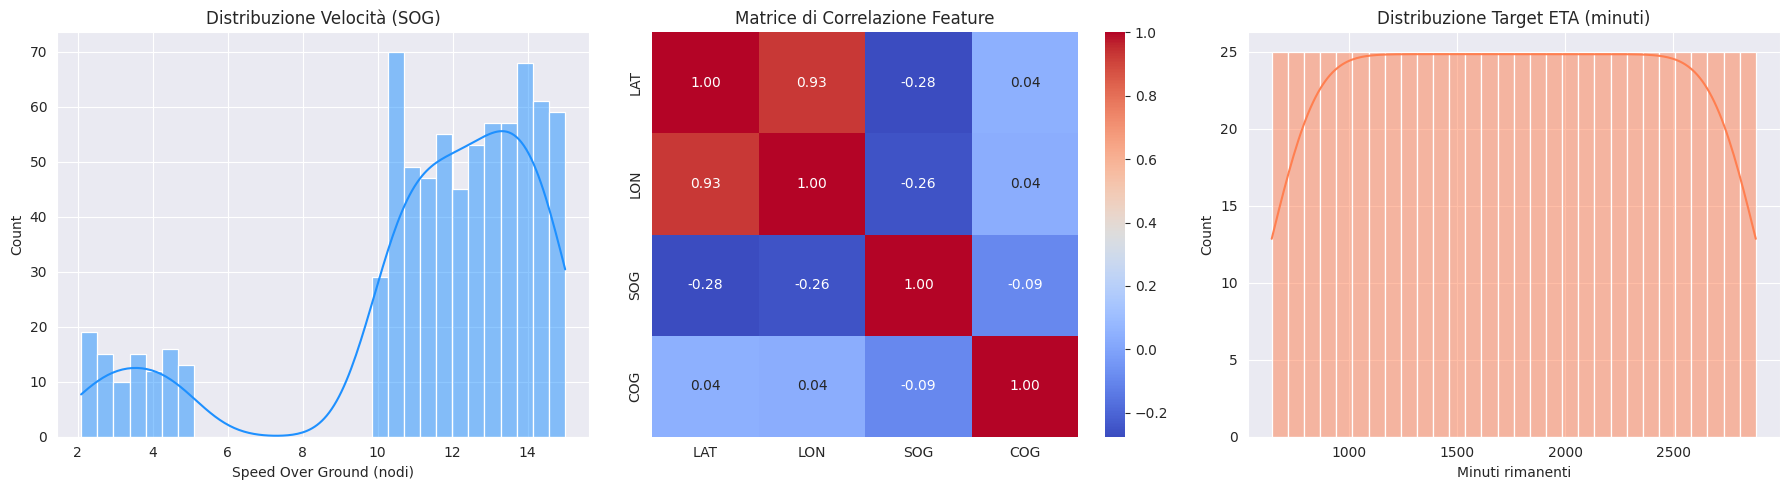

In [32]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 500, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, :x.size(1), :])


class SpatioTemporalTransformer(nn.Module):
    """
    Transformer encoder per regressione dell'ETA residua (minuti).
    Migliorato con head di regressione multi-layer e dropout.
    """
    def __init__(self, input_dim: int = 9, d_model: int = 64, n_heads: int = 4,
                 n_layers: int = 2, dim_ff: int = 256, dropout: float = 0.1):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        self.pos  = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = n_heads,
            dim_feedforward= dim_ff,
            dropout        = dropout,
            batch_first    = True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        # Head di regressione migliorata
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, src: torch.Tensor) -> torch.Tensor:
        x = self.proj(src)
        x = self.pos(x)
        x = self.transformer(x)
        return self.head(x[:, -1, :]).squeeze(-1)


model = SpatioTemporalTransformer().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametri trainabili: {total_params:,}")
print(model)

print("--- Exploratory Data Analysis (EDA) ---")
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribuzione della velocità
sns.histplot(df['SOG'], bins=30, kde=True, ax=ax[0], color='dodgerblue')
ax[0].set_title('Distribuzione Velocità (SOG)')
ax[0].set_xlabel('Speed Over Ground (nodi)')

# 2. Matrice di correlazione
corr_cols = ['LAT', 'LON', 'SOG', 'COG']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', ax=ax[1], fmt=".2f")
ax[1].set_title('Matrice di Correlazione Feature')

# 3. Distribuzione target ETA
if 'target_eta_minutes' not in df.columns:
    df_tmp = df.copy()
    df_tmp['Actual_Arrival_Time'] = pd.to_datetime(df_tmp['Actual_Arrival_Time'])
    df_tmp['Timestamp'] = pd.to_datetime(df_tmp['Timestamp'])
    df_tmp['target_eta_minutes'] = (df_tmp['Actual_Arrival_Time'] - df_tmp['Timestamp']).dt.total_seconds() / 60.0
    sns.histplot(df_tmp['target_eta_minutes'], bins=30, kde=True, ax=ax[2], color='coral')
else:
    sns.histplot(df['target_eta_minutes'], bins=30, kde=True, ax=ax[2], color='coral')
ax[2].set_title('Distribuzione Target ETA (minuti)')
ax[2].set_xlabel('Minuti rimanenti')

plt.tight_layout()
plt.show()

## 4. Training con Early Stopping

### Funzioni di Valutazione
Metriche complete: MAE, RMSE, R², MAPE per valutazione rigorosa dei modelli.

In [33]:
def evaluate_model(model_fn, data_loader, device) -> dict:
    """Valuta un modello e restituisce metriche complete."""
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for bx, by in data_loader:
            bx, by = bx.to(device), by.to(device)
            preds = model_fn(bx)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(by.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)

    # MAPE (evitare divisione per zero)
    mask = all_targets != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((all_targets[mask] - all_preds[mask]) / all_targets[mask])) * 100
    else:
        mape = float('inf')

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}


def print_metrics(name: str, metrics: dict):
    """Stampa le metriche in formato tabellare."""
    print(f"\n{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(f"  MAE:  {metrics['MAE']:.2f} min")
    print(f"  RMSE: {metrics['RMSE']:.2f} min")
    print(f"  R²:   {metrics['R2']:.4f}")
    print(f"  MAPE: {metrics['MAPE']:.2f}%")
    print(f"{'='*50}")

Avvio training (max 200 epoche, early stopping patience=8)...

Epoch 01/200 | Train: 1806.7468 | Val: 1684.0362 | LR: 1.00e-03
Epoch 05/200 | Train: 1771.5350 | Val: 1644.2289 | LR: 1.00e-03
Epoch 10/200 | Train: 1652.4792 | Val: 1512.8857 | LR: 1.00e-03
Epoch 15/200 | Train: 1408.1801 | Val: 1254.7425 | LR: 1.00e-03
Epoch 20/200 | Train: 1010.0267 | Val: 860.7925 | LR: 1.00e-03
Epoch 25/200 | Train: 619.8641 | Val: 480.1558 | LR: 1.00e-03
Epoch 30/200 | Train: 259.4238 | Val: 271.4430 | LR: 1.00e-03
Epoch 35/200 | Train: 163.2875 | Val: 169.2310 | LR: 1.00e-03
Epoch 40/200 | Train: 158.0446 | Val: 175.4892 | LR: 5.00e-04

Early stopping a epoca 42 (val_loss non migliora da 8 epoche).

Best val loss: 142.9934


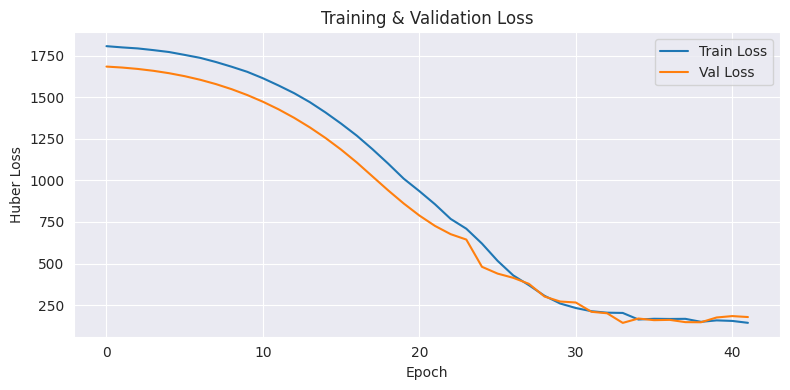

In [34]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.SmoothL1Loss()   # Huber loss — robusta agli outlier
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# Early stopping
EPOCHS        = 200
PATIENCE      = 8
best_val_loss = float('inf')
patience_cnt  = 0
best_state    = None
history       = {'train': [], 'val': []}

print(f"Avvio training (max {EPOCHS} epoche, early stopping patience={PATIENCE})...\n")

for epoch in range(1, EPOCHS + 1):

    # --- Train ---
    model.train()
    train_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            val_loss += criterion(model(bx), by).item()
    val_loss /= len(val_loader)

    scheduler.step(val_loss)
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:02d}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {lr_now:.2e}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_cnt  = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"\nEarly stopping a epoca {epoch} (val_loss non migliora da {PATIENCE} epoche).")
            break

# Ripristina i pesi migliori
model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

# Plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(history['train'], label='Train Loss')
plt.plot(history['val'],   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss')
plt.title('Training & Validation Loss')
plt.legend(); plt.tight_layout(); plt.show()

## 5. Inference & Anomaly Detection

In [36]:
# Inference su tutte le sequenze (train + val, per la visualizzazione completa)
full_loader = DataLoader(full_dataset, batch_size=16, shuffle=False)

model.eval()
preds = []
with torch.no_grad():
    for bx, _ in full_loader:
        bx = bx.to(device)
        preds.extend(model(bx).cpu().numpy().tolist())

meta = meta.copy()
meta['Predicted_ETA_Minutes'] = preds
meta['Timestamp']    = pd.to_datetime(meta['Timestamp'])
meta['Declared_ETA'] = pd.to_datetime(meta['Declared_ETA'])

meta['Predicted_ETA'] = meta.apply(
    lambda r: r['Timestamp'] + pd.Timedelta(minutes=float(r['Predicted_ETA_Minutes'])), axis=1
)
meta['Delta_Minutes'] = (
    meta['Predicted_ETA'] - meta['Declared_ETA']
).dt.total_seconds() / 60.0

# Soglia anomalia: scarto > 15% della durata dichiarata totale
declared_total_min = (meta['Declared_ETA'].iloc[0] - meta['Timestamp'].iloc[0]).total_seconds() / 60.0
threshold = 0.15 * declared_total_min
meta['Anomaly_Flag'] = meta['Delta_Minutes'].abs() > threshold

n_anomalies = meta['Anomaly_Flag'].sum()
print(f"Soglia anomalia: ±{threshold:.1f} min  |  Anomalie rilevate: {n_anomalies}/{len(meta)}")
display(meta[['Timestamp', 'Declared_ETA', 'Predicted_ETA', 'Delta_Minutes', 'Anomaly_Flag']].tail(10))

Soglia anomalia: ±362.2 min  |  Anomalie rilevate: 40/730


,Timestamp,Declared_ETA,Predicted_ETA,Delta_Minutes,Anomaly_Flag
720,2024-01-22 20:45:00,2024-01-23 07:00:00,2024-01-23 07:33:54.118652343,33.901978,False
721,2024-01-22 21:00:00,2024-01-23 07:00:00,2024-01-23 07:51:10.543212890,51.175720,False
722,2024-01-22 21:15:00,2024-01-23 07:00:00,2024-01-23 08:06:52.316894531,66.871948,False
723,2024-01-22 21:30:00,2024-01-23 07:00:00,2024-01-23 08:22:43.344726562,82.722412,False
724,2024-01-22 21:45:00,2024-01-23 07:00:00,2024-01-23 08:32:07.298583984,92.121643,False
725,2024-01-22 22:00:00,2024-01-23 07:00:00,2024-01-23 08:43:47.519531250,103.791992,False
726,2024-01-22 22:15:00,2024-01-23 07:00:00,2024-01-23 09:02:09.755859375,122.162598,False
727,2024-01-22 22:30:00,2024-01-23 07:00:00,2024-01-23 09:17:45.007324218,137.750122,False
728,2024-01-22 22:45:00,2024-01-23 07:00:00,2024-01-23 09:36:13.494873046,156.224915,False
729,2024-01-22 23:00:00,2024-01-23 07:00:00,2024-01-23 09:57:04.753417968,177.079224,False


## 6. Explainability — Attention Heatmap Reale

Estraiamo i pesi di attenzione **reali** dall'ultimo layer del Transformer tramite un forward hook, senza mock casuali.

In [ ]:


class AttentionExtractor:
    """
    Registra un hook sul self-attention dell'ultimo layer del Transformer
    per estrarre i pesi di attenzione durante il forward pass.
    """
    def __init__(self, model: SpatioTemporalTransformer):
        self.attn_weights = None
        # Aggancia l'hook al layer self-attention dell'ultimo encoder layer
        last_layer = model.transformer.layers[-1]
        self._hook = last_layer.self_attn.register_forward_hook(self._hook_fn)

    def _hook_fn(self, module, input, output):
        # output[1] contiene i pesi di attenzione medi sulle teste se average_attn_weights=True (default)
        # shape: (B, S, S)
        if isinstance(output, tuple) and len(output) > 1 and output[1] is not None:
            self.attn_weights = output[1].detach().cpu()

    def remove(self):
        self._hook.remove()


# Selezioniamo il campione con più anomalie nel delta
sample_idx = meta['Delta_Minutes'].abs().idxmax()
print(f"Campione scelto per explainability: indice {sample_idx}")
print(f"  Delta ETA: {meta.loc[sample_idx, 'Delta_Minutes']:.1f} min")
print(f"  Anomalia rilevata: {meta.loc[sample_idx, 'Anomaly_Flag']}")

extractor = AttentionExtractor(model)

model.eval()
with torch.no_grad():
    sample_tensor = X_tensor[sample_idx].unsqueeze(0).to(device)   # (1, seq_len, F)
    _ = model(sample_tensor)

extractor.remove()

if extractor.attn_weights is not None:
    # Pesi di attenzione dell'ultimo token sugli step precedenti — forma (seq_len,)
    attn = extractor.attn_weights[0, -1, :].numpy()  # (seq_len,)
    # Normalizzazione [0, 1]
    attn = (attn - attn.min()) / (attn.max() - attn.min() + 1e-9)
    print(f"\nAttenzione estratta dal modello — shape: {attn.shape}")
else:
    print("Hook non ha catturato i pesi — PyTorch potrebbe non restituirli in questa configurazione.")
    print("Fallback: aggregazione dei gradienti (Gradient Attention).")
    # Fallback: gradient-based importance sul sample
    model.train()  # serve per abilitare i gradienti
    sample_tensor.requires_grad_(True)
    out = model(sample_tensor)
    out.backward()
    # Gradient norm per timestep come proxy dell'importanza
    grads = sample_tensor.grad[0].abs().mean(dim=-1).detach().cpu().numpy()  # (seq_len,)
    attn  = (grads - grads.min()) / (grads.max() - grads.min() + 1e-9)
    model.eval()

Campione scelto per explainability: indice 636
  Delta ETA: -644.1 min
  Anomalia rilevata: True
Hook non ha catturato i pesi — PyTorch potrebbe non restituirli in questa configurazione.
Fallback: aggregazione dei gradienti (Gradient Attention).


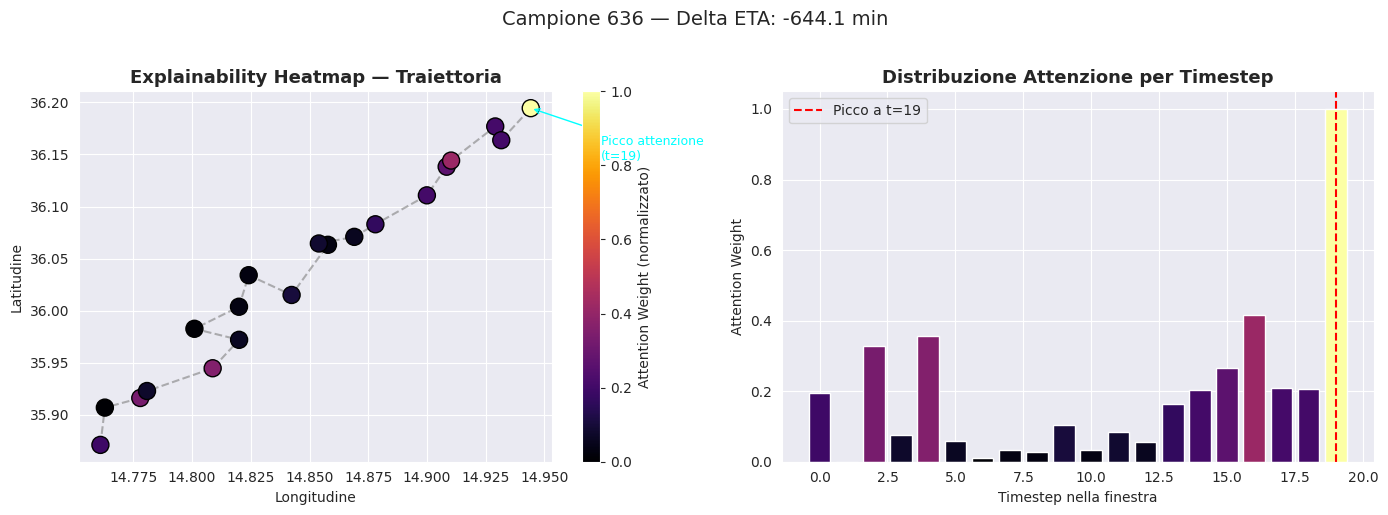

In [ ]:
lats_window, lons_window = coord_windows[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_style("darkgrid")

# --- Plot 1: Heatmap spaziale ---
ax = axes[0]
sc = ax.scatter(lons_window, lats_window, c=attn, cmap='inferno',
                s=150, edgecolors='k', zorder=2)
ax.plot(lons_window, lats_window, color='gray', linestyle='--', zorder=1, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Attention Weight (normalizzato)')
ax.set_title('Explainability Heatmap — Traiettoria', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitudine'); ax.set_ylabel('Latitudine')

# Evidenzia il punto con attenzione massima
peak_idx = np.argmax(attn)
ax.annotate(f'Picco attenzione\n(t={peak_idx})',
            xy=(lons_window[peak_idx], lats_window[peak_idx]),
            xytext=(lons_window[peak_idx] + 0.03, lats_window[peak_idx] - 0.05),
            arrowprops=dict(arrowstyle='->', color='cyan'),
            color='cyan', fontsize=9)

# --- Plot 2: Attention nel tempo ---
ax2 = axes[1]
ax2.bar(range(len(attn)), attn, color=cm.inferno(attn))
ax2.set_xlabel('Timestep nella finestra'); ax2.set_ylabel('Attention Weight')
ax2.set_title('Distribuzione Attenzione per Timestep', fontsize=13, fontweight='bold')
ax2.axvline(peak_idx, color='red', linestyle='--', label=f'Picco a t={peak_idx}')
ax2.legend()

plt.suptitle(f'Campione {sample_idx} — Delta ETA: {meta.loc[sample_idx, "Delta_Minutes"]:.1f} min',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [39]:

import folium

# Prendi le coordinate e convertiamo subito i centri in float nativi
lats_window, lons_window = coord_windows[sample_idx]
center_lat = float(np.mean(lats_window))
center_lon = float(np.mean(lons_window))

# Inizializza la mappa con stile scuro
m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles='CartoDB dark_matter')

# Traccia la traiettoria: convertiamo tutta la lista di coordinate in float
points = [(float(lat), float(lon)) for lat, lon in zip(lats_window, lons_window)]
folium.PolyLine(points, color="white", weight=2, opacity=0.4).add_to(m)

# Aggiungiamo i marker
for i in range(len(lats_window)):
    # Castiamo a float tutto ciò che passiamo a Folium
    radius = float(3 + (attn[i] * 12))

    is_peak = (i == peak_idx)
    marker_color = "#00FFFF" if is_peak else "#FF4500"

    folium.CircleMarker(
        location=[float(lats_window[i]), float(lons_window[i])],
        radius=radius,
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=float(0.5 + (attn[i] * 0.4)),
        tooltip=f"Step: {i} | Attention: {float(attn[i]):.3f} | SOG: {float(df.iloc[sample_idx + i]['SOG']):.1f} nodi"
    ).add_to(m)

print("Mappa Interattiva Folium Generata. Scorri per visualizzare il focus del Transformer:")
display(m)

Mappa Interattiva Folium Generata. Scorri per visualizzare il focus del Transformer:


Avvio training LSTM Baseline (con Early Stopping)...
  LSTM Epoch 001/200 | Train: 1805.0070 | Val: 1686.5911 | LR: 1.00e-03
  LSTM Epoch 010/200 | Train: 1796.9546 | Val: 1677.8567 | LR: 1.00e-03
  LSTM Epoch 020/200 | Train: 1782.3280 | Val: 1662.8964 | LR: 1.00e-03
  LSTM Epoch 030/200 | Train: 1763.9212 | Val: 1643.1115 | LR: 1.00e-03
  LSTM Epoch 040/200 | Train: 1737.9744 | Val: 1618.4687 | LR: 1.00e-03
  LSTM Epoch 050/200 | Train: 1709.6131 | Val: 1588.8564 | LR: 1.00e-03
  LSTM Epoch 060/200 | Train: 1674.8051 | Val: 1554.1743 | LR: 1.00e-03
  LSTM Epoch 070/200 | Train: 1636.6731 | Val: 1514.3581 | LR: 1.00e-03
  LSTM Epoch 080/200 | Train: 1591.9183 | Val: 1469.3879 | LR: 1.00e-03
  LSTM Epoch 090/200 | Train: 1540.8046 | Val: 1419.2873 | LR: 1.00e-03
  LSTM Epoch 100/200 | Train: 1486.9544 | Val: 1364.1142 | LR: 1.00e-03
  LSTM Epoch 110/200 | Train: 1425.4838 | Val: 1303.9405 | LR: 1.00e-03
  LSTM Epoch 120/200 | Train: 1362.3805 | Val: 1238.8439 | LR: 1.00e-03
  LSTM Epoc

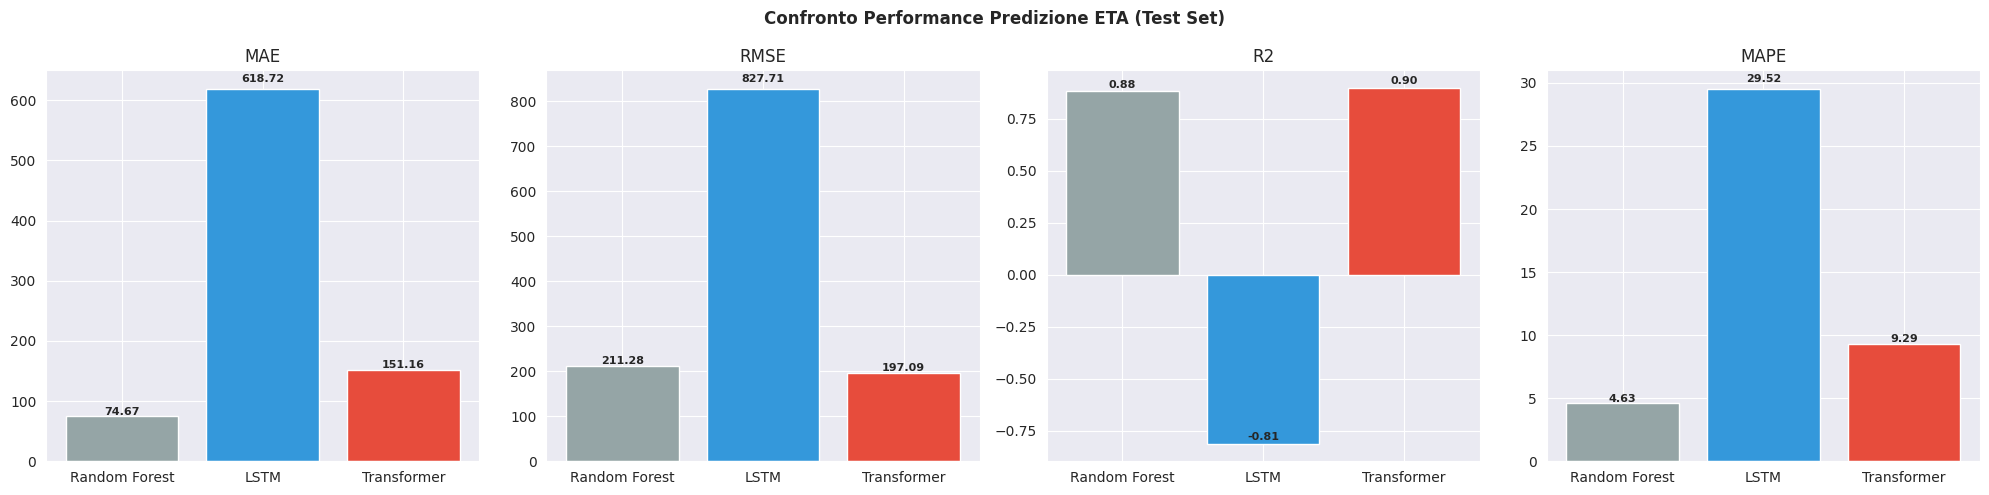

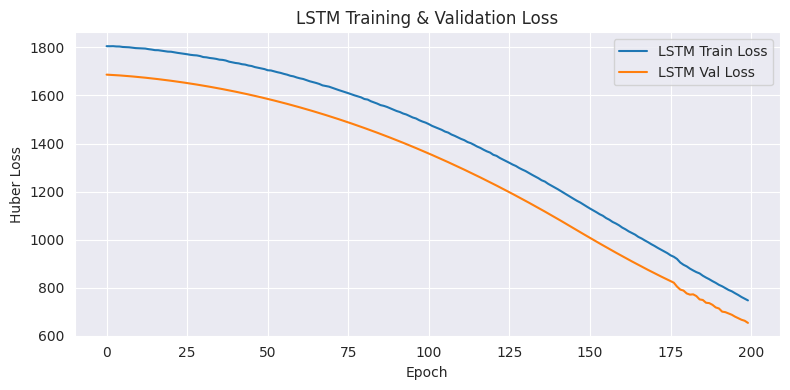

In [40]:
import time

# --- 1. Training del modello LSTM con Early Stopping ---
lstm_model = SpatioTemporalLSTM().to(device)
optimizer_lstm = optim.AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_lstm = nn.SmoothL1Loss()
scheduler_lstm = optim.lr_scheduler.ReduceLROnPlateau(optimizer_lstm, patience=5, factor=0.5)

LSTM_EPOCHS = 200
LSTM_PATIENCE = 10
best_lstm_val_loss = float('inf')
best_lstm_state = None
lstm_patience_cnt = 0
lstm_history = {'train': [], 'val': []}

print("Avvio training LSTM Baseline (con Early Stopping)...")

for epoch in range(1, LSTM_EPOCHS + 1):
    lstm_model.train()
    train_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer_lstm.zero_grad()
        loss = criterion_lstm(lstm_model(bx), by)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer_lstm.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            val_loss += criterion_lstm(lstm_model(bx), by).item()
    val_loss /= len(val_loader)

    scheduler_lstm.step(val_loss)
    lstm_history['train'].append(train_loss)
    lstm_history['val'].append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        lr_now = optimizer_lstm.param_groups[0]['lr']
        print(f"  LSTM Epoch {epoch:03d}/{LSTM_EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {lr_now:.2e}")

    if val_loss < best_lstm_val_loss:
        best_lstm_val_loss = val_loss
        best_lstm_state = {k: v.cpu().clone() for k, v in lstm_model.state_dict().items()}
        lstm_patience_cnt = 0
    else:
        lstm_patience_cnt += 1
        if lstm_patience_cnt >= LSTM_PATIENCE:
            print(f"  LSTM Early stopping a epoca {epoch}")
            break

lstm_model.load_state_dict(best_lstm_state)
print(f"  LSTM Best val loss: {best_lstm_val_loss:.4f}")

# --- 2. Valutazione Comparativa sul TEST Set ---
model.eval()
lstm_model.eval()

transformer_metrics = evaluate_model(model, test_loader, device)
lstm_metrics = evaluate_model(lstm_model, test_loader, device)

# Random Forest sul test set
X_test_rf = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))]).numpy().reshape(n_test, -1)
y_test_rf = torch.stack([test_dataset[i][1] for i in range(len(test_dataset))]).numpy()
rf_preds = rf_model.predict(X_test_rf)
rf_metrics = {
    'MAE': mean_absolute_error(y_test_rf, rf_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test_rf, rf_preds)),
    'R2': r2_score(y_test_rf, rf_preds),
    'MAPE': np.mean(np.abs((y_test_rf - rf_preds) / np.where(y_test_rf != 0, y_test_rf, 1))) * 100
}

print_metrics("Random Forest (Baseline)", rf_metrics)
print_metrics("LSTM", lstm_metrics)
print_metrics("Spatio-Temporal Transformer", transformer_metrics)

# --- 3. Visualizzazione Risultati ---
models_names = ['Random Forest', 'LSTM', 'Transformer']
metrics_keys = ['MAE', 'RMSE', 'R2', 'MAPE']
all_metrics = [rf_metrics, lstm_metrics, transformer_metrics]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#95a5a6', '#3498db', '#e74c3c']

for idx, key in enumerate(metrics_keys):
    values = [m[key] for m in all_metrics]
    axes[idx].bar(models_names, values, color=colors)
    axes[idx].set_title(key)
    for i, v in enumerate(values):
        axes[idx].text(i, v + abs(v)*0.02, f"{v:.2f}", ha='center', fontweight='bold', fontsize=8)

plt.suptitle('Confronto Performance Predizione ETA (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

# --- 4. Learning Curves LSTM ---
plt.figure(figsize=(8, 4))
plt.plot(lstm_history['train'], label='LSTM Train Loss')
plt.plot(lstm_history['val'], label='LSTM Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss')
plt.title('LSTM Training & Validation Loss')
plt.legend(); plt.tight_layout(); plt.show()

## 7. Export del Modello

In [ ]:
# Salvataggio pesi e scaler
import pickle

torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_dim': 9,
        'd_model':   64,
        'n_heads':    4,
        'n_layers':   2,
        'dim_ff':   256,
        'dropout':  0.1
    }
}, 'ais_eta_transformer.pt')

with open('ais_scaler.pkl', 'wb') as f:
    pickle.dump(processor.scaler, f)

print("Modello salvato: ais_eta_transformer.pt")
print("Scaler salvato : ais_scaler.pkl")

Modello salvato: ais_eta_transformer.pt
Scaler salvato : ais_scaler.pkl
